<a href="https://colab.research.google.com/github/prateekP1906/AML-LAB/blob/main/AML_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd #import pandas for table structured data
from sklearn.datasets import load_breast_cancer #import the built in cancer dataset

data = load_breast_cancer(as_frame=True) #Load dataset directly formatted as a pasdas dataframce
df = data.frame #save the full data table (measurement + diagnosis)

print(f"Dataset shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})") #print the dimensions of the table


Dataset shape: (569, 31) (Rows: 569, Columns: 31)


In [17]:

X = data.data.values #Extract all 30 tumor measurement columns into X (the input feaftures)
y = data.target.values #Extract the diagnosis column into y (0 for malignant, 1 for benign)

print(f"Features (X) isolated! Shape: {X.shape}") #Print the shape of X to confirm 569 samples with 30  measurement each
print(f"Diagnosis (y) isolated! Shape: {y.shape}") #Print the shape of Y to confirm 569 target answers


Features (X) isolated! Shape: (569, 30)
Diagnosis (y) isolated! Shape: (569,)


In [18]:
from sklearn.model_selection import train_test_split #Import the helper divides the data in training and test

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42) #splits data: 70% for training and 30% for testing

print(f"Training data size: {X_train.shape[0]}")#Print the total count of patient in training sets
print(f"Testing data size: {X_test.shape[0]}")#print the total count of patient in testing sets

Training data size: 398
Testing data size: 171


In [19]:
from sklearn.preprocessing import StandardScaler #import the standardscalar tool to numerical feature range

scaler = StandardScaler() #instance of the scaler

X_train_scaled = scaler.fit_transform(X_train) #training data mean and scale the training features

X_test_scaled = scaler.transform(X_test) #Scale the testing features using training data

print("Data pre-processing (scaling) complete!") #printing corfirming data normalisation

Data pre-processing (scaling) complete!


In [20]:
from sklearn.tree import DecisionTreeClassifier #Importing the DecisionTreeClasifier
from sklearn.linear_model import LogisticRegression #Importing the LogisticRegression

dt_model = DecisionTreeClassifier() #untrained instance of DTM
lr_model = LogisticRegression() #untrained instance of LRM

dt_model.fit(X_train_scaled, Y_train) #training DTM on scaled training features and answers
lr_model.fit(X_train_scaled, Y_train) #training LRM on scaled training features and answers

print("Both Decision Tree and Logistic Regression models have have trained!") #confirmation message

Both Decision Tree and Logistic Regression models have have trained!


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #import the evaluation metrics
import pandas as pd #pandas for table format

dt_predictions = dt_model.predict(X_test_scaled) #trained DTM predict the test set diagnosis
lr_predictions = lr_model.predict(X_test_scaled) #trained LRM predict the test set diagnosis

dc_acc = accuracy_score(Y_test, dt_predictions) #Calculate the acc of DTM
dc_prec = precision_score(Y_test, dt_predictions) #Calculate the precision of DTM
dc_rec = recall_score(Y_test, dt_predictions) #Calculate the recall score of DTM
dc_f1 = f1_score(Y_test, dt_predictions) #Calculate the f1 score of DTM

lr_acc = accuracy_score(Y_test, lr_predictions) #Calculate the acc of LRM
lr_prec = precision_score(Y_test, lr_predictions) #Calculate the precision of LRM
lr_rec = recall_score(Y_test, lr_predictions) #Calculate the recall score of LRM
lr_f1 = f1_score(Y_test, lr_predictions) #Calculate the f1 score of LRM

results_table = pd.DataFrame({ #Dataframe table combining the metrics of both models
    "Metric" : ["Accuracy", "Precision", "Recall", "F1_score"],
    "Decision Tree" : [dc_acc * 100, dc_prec * 100, dc_rec * 100, dc_f1 * 100],
    "Logistic Regression" : [lr_acc * 100, lr_prec * 100, lr_rec * 100, lr_f1 * 100]
})

results_table = results_table.round(2) #Round every decimal value to 2
results_table["Decision Tree"] = results_table["Decision Tree"].astype(str) + '%' #adding the percentage sign to every predicted value of DTM
results_table["Logistic Regression"] = results_table["Logistic Regression"].astype(str) + '%' #adding the percentage sign to every predicted value of LRM

display(results_table) #displaying the table

,Metric,Decision Tree,Logistic Regression
0,Accuracy,93.57%,98.25%
1,Precision,96.19%,99.07%
2,Recall,93.52%,98.15%
3,F1_score,94.84%,98.6%


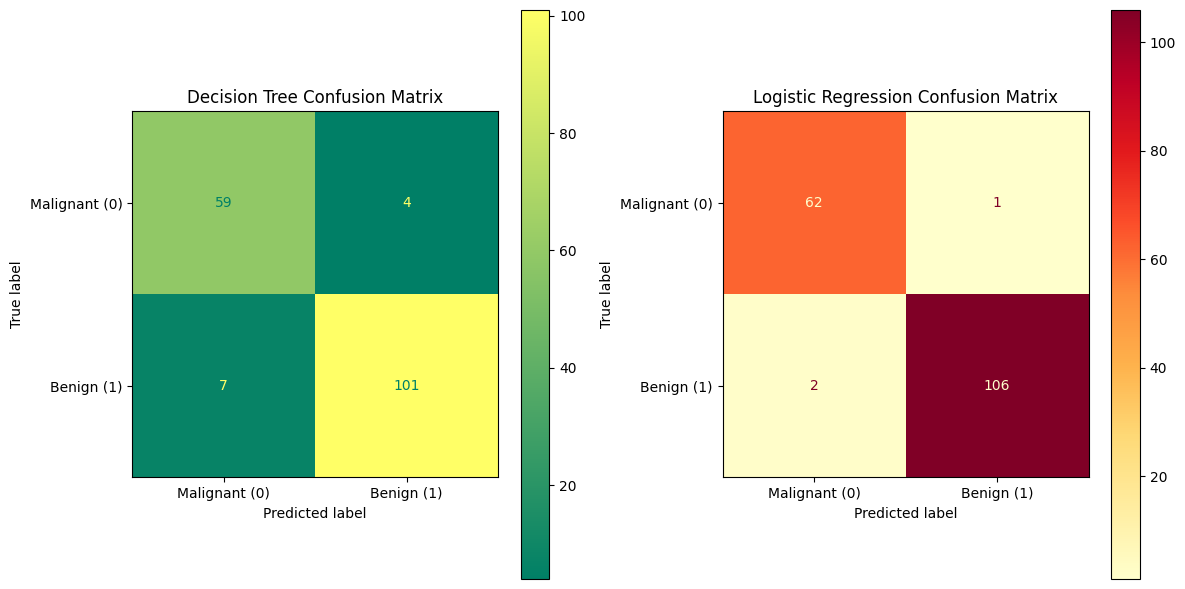

In [31]:
import matplotlib.pyplot as plt #import matplotlib for configuring and drawing graphs
from sklearn.metrics import ConfusionMatrixDisplay #import the tools for plotting confsusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 6)) #create a figure 1 row and 2 subplots of size 12x6

ConfusionMatrixDisplay.from_predictions( #subplots (axes[0]) with summer shading
    Y_test,
    dt_predictions,
    display_labels=["Malignant (0)", "Benign (1)"],
    cmap="summer",
    ax = axes[0]
)

axes[0].set_title("Decision Tree Confusion Matrix") # header title above the left side matrix

ConfusionMatrixDisplay.from_predictions( #subplots (axes[1]) with summer shading
    Y_test,
    lr_predictions,
    display_labels=["Malignant (0)", "Benign (1)"],
    cmap="YlOrRd",
    ax = axes[1]
)

axes[1].set_title("Logistic Regression Confusion Matrix") # header title above the left side matrix

plt.tight_layout()
plt.show() #output and display
